In [ ]:
 import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim

import math
from collections import defaultdict

!pip install nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

### Downloading the Data

Using the HuggingFace Datasets Library to download the dataset.

**Note:** The raw im2latex-100k dataset [on Zenodo](https://zenodo.org/records/56198#.V2p0KTXT6eA) contains full A4-page PNG images with transparent backgrounds, where only the formula is rendered and the rest of the page is empty.The [HuggingFace version](https://huggingface.co/datasets/yuntian-deng/im2latex-100k) of this dataset has already performed preprocessing. So, images are RGB PNGs at a fixed size of 320x64 pixels with white backgrounds and the formula is cropped and centered.

In [ ]:
from datasets import load_dataset
ds = load_dataset("yuntian-deng/im2latex-100k")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-93885635ef7c68(…):   0%|          | 0.00/273M [00:00<?, ?B/s]

data/test-00000-of-00001-fce261550cd3f5d(…):   0%|          | 0.00/34.0M [00:00<?, ?B/s]

data/val-00000-of-00001-3f88ebb0c1272ccf(…):   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/55033 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6810 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/6072 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['formula', 'filename', 'image'],
        num_rows: 55033
    })
    test: Dataset({
        features: ['formula', 'filename', 'image'],
        num_rows: 6810
    })
    val: Dataset({
        features: ['formula', 'filename', 'image'],
        num_rows: 6072
    })
}) 

Looking at a single sample:
Formula: \widetilde \gamma _ { \mathrm { h o p f } } \simeq \sum _ { n > 0 } \widetilde { G } _ { n } { \frac { ( - a ) ^ { n } } { 2 ^ { 2 n - 1 } } }
Filename: 66667cee5b.png



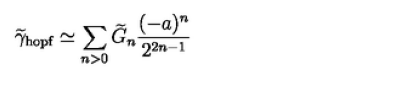

Image type: <class 'PIL.PngImagePlugin.PngImageFile'>
Image size: (320, 64)


In [ ]:
# print the dataset structure
print(ds, "\n")

# look at a single sample
print("Looking at a single sample:")
sample = ds['train'][0]
print("Formula:", sample['formula'])
print("Filename:", sample['filename'])
print()
img = sample['image']
plt.figure(figsize=(5, 2))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()
print("Image type:", type(sample['image']))
print("Image size:", sample['image'].size)

In [ ]:
# dataset summary
for split in ['train', 'test', 'val']:
    sample = ds[split][0]
    print(f"{split:>6} split: {len(ds[split]):>6} samples | "
          f"Image size: {sample['image'].size} ")

 train split:  55033 samples | Image size: (320, 64) 
  test split:   6810 samples | Image size: (320, 64) 
   val split:   6072 samples | Image size: (320, 64) 


### Dataset Exploration

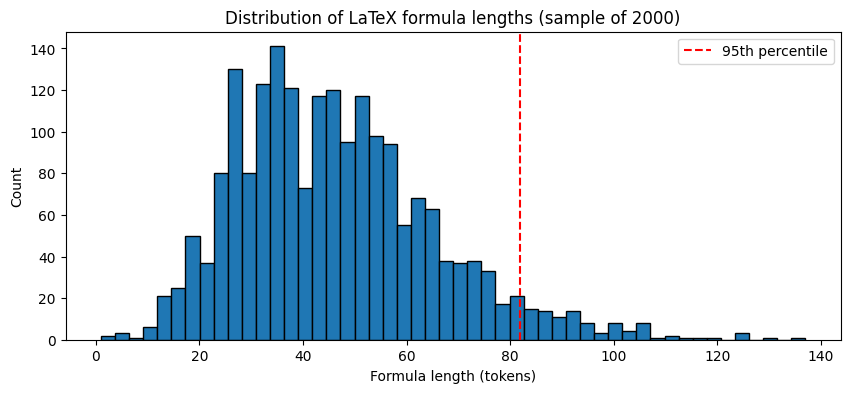


Max length: 137
Mean length: 46.4
95th percentile: 82


In [ ]:
# visualizing length of the formulas in dataset
lengths = [len(ds['train'][i]['formula'].split()) for i in range(2000)]

plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, edgecolor='black')
plt.xlabel("Formula length (tokens)")
plt.ylabel("Count")
plt.title("Distribution of LaTeX formula lengths (sample of 2000)")
plt.axvline(np.percentile(lengths, 95), color='red', linestyle='--', label='95th percentile')
plt.legend()
plt.show()
print()
print(f"Max length: {max(lengths)}")
print(f"Mean length: {np.mean(lengths):.1f}")
print(f"95th percentile: {np.percentile(lengths, 95):.0f}")

### Building Vocabulary

Converting LaTeX token strings into integers that the neural network can process. This is done by scanning every formula in the training set, collecting all unique tokens, and assigning each one a unique integer ID.

Four special token IDs are allocated:
- `<PAD>`: used to pad shorter sequences to match the longest one in a batch
- `<START>`: prepended to every formula to signal the decoder to begin generating
- `<END>`: appended to every formula to signal the decoder to stop
- `<UNK>`: replaces any token at inference time that wasn't seen during training

In [ ]:
class Vocabulary:
  def __init__(self):
    self.token2id = {'<PAD>': 0, '<START>': 1, '<END>': 2, '<UNK>': 3}
    self.id2token = {0: '<PAD>', 1: '<START>', 2: '<END>', 3: '<UNK>'}

  def build(self, formulas, min_freq=2):
    """
    Scan all formulas and add any token that appears
    at least min_freq times to the vocabulary.
    """
    counter = Counter()
    for formula in formulas:
        tokens = formula.split()
        counter.update(tokens)

    for token, freq in counter.items():
        # keep tokens that occur once or twice
        if freq >= min_freq and token not in self.token2id:
            idx = len(self.token2id)
            self.token2id[token] = idx
            self.id2token[idx] = token

    print(f"Vocabulary built: {len(self.token2id)} unique tokens")

  def encode(self, formula):
      """Convert a formula string to a list of integer IDs."""
      tokens = formula.split()
      return ([self.token2id['<START>']] + [self.token2id.get(t, self.token2id['<UNK>']) for t in tokens] + [self.token2id['<END>']])

  def decode(self, ids):
      """Convert a list of integer IDs back to a formula string."""
      tokens = []
      for i in ids:
          token = self.id2token.get(i, '<UNK>')
          if token == '<END>':
              break
          if token not in ('<PAD>', '<START>'):
              tokens.append(token)
      return ' '.join(tokens)

  def __len__(self):
      return len(self.token2id)

In [ ]:
# build vocabulary using only the training set
vocab = Vocabulary()
vocab.build([ds['train'][i]['formula'] for i in range(len(ds['train']))])
print(f"Total vocabulary size: {len(vocab)}")
print(f"Most common tokens: {list(vocab.token2id.keys())[4:15]}")

Vocabulary built: 468 unique tokens
Total vocabulary size: 468
Most common tokens: ['\\widetilde', '\\gamma', '_', '{', '\\mathrm', 'h', 'o', 'p', 'f', '}', '\\simeq']


In [ ]:
# sanity check! :p
sample_formula = ds['train'][0]['formula']
encoded = vocab.encode(sample_formula)
decoded = vocab.decode(encoded)

print("Original: ", sample_formula[:80])
print("Encoded:  ", encoded[:10])
print("Decoded:  ", decoded[:80])

Original:  \widetilde \gamma _ { \mathrm { h o p f } } \simeq \sum _ { n > 0 } \widetilde {
Encoded:   [1, 4, 5, 6, 7, 8, 7, 9, 10, 11]
Decoded:   \widetilde \gamma _ { \mathrm { h o p f } } \simeq \sum _ { n > 0 } \widetilde {


In [ ]:
special = ['<PAD>', '<START>', '<END>', '<UNK>']
single_chars = [t for t in vocab.token2id if len(t) == 1 and t not in special]
latex_commands = [t for t in vocab.token2id if t.startswith('\\')]
other = [t for t in vocab.token2id if t not in special and len(t) != 1 and not t.startswith('\\')]

print(f"Single chars:       {len(single_chars)}")
print(f"LaTeX commands:     {len(latex_commands)}")
print(f"Other (digits etc): {len(other)}")

Single chars:       90
LaTeX commands:     362
Other (digits etc): 13


In [ ]:
print(latex_commands[:10])

['\\widetilde', '\\gamma', '\\mathrm', '\\simeq', '\\sum', '\\frac', '\\cal', '\\', '\\pi', '\\sqrt']


In [ ]:
print(single_chars)

['_', '{', 'h', 'o', 'p', 'f', '}', 'n', '>', '0', 'G', '(', '-', 'a', ')', '^', '2', '1', 'L', 'g', 'i', 'j', '=', ',', '\\', 'H', 'k', 'S', 's', 't', 'N', '5', '3', '+', '.', '*', 'd', 'J', 'B', 'F', 'e', 'x', 'q', 'm', 'P', 'w', 'D', 'V', 'c', 'A', 'l', '8', 'T', 'y', 'z', '4', 'u', 'R', 'C', '[', ']', 'K', '~', 'X', 'W', 'b', '/', ':', '&', '|', 'r', ';', 'Q', '!', '9', 'Z', 'M', '<', 'E', 'U', 'O', '6', 'v', '7', 'Y', 'I', "'", '"', '`', '?']


In [ ]:
print(other)

['--', 'ule', '0.14', 'mm', '8.5', '[object', 'Object]', 'pt', '---', 'cm', '0.1', '3.1', '3.2']


The 13 'other' tokens are all noise. It includes length units
(cm, pt, mm) and numeric arguments from \rule and \hspace commands, and JavaScript elements ([object, Object])

### Buildiing the Dataset and DataLoader

In [ ]:
MAX_SEQ_LEN = 150

# pipeline to transform images, [1, 64, 320]
image_transform = transforms.Compose([transforms.Grayscale(),
                  transforms.ToTensor(),
                  transforms.Normalize(mean=[0.5], std=[0.5])])

In [ ]:
class Im2LatexDataset(Dataset):
  def __init__(self, hf_split, vocab, transform=None, max_seq_len=MAX_SEQ_LEN):
      self.data = hf_split
      self.vocab = vocab
      self.transform = transform
      self.max_seq_len = max_seq_len

  def __len__(self):
      return len(self.data)

  def __getitem__(self, idx):
      sample = self.data[idx]

      img = sample['image']
      if self.transform:
          img = self.transform(img)

      encoded = self.vocab.encode(sample['formula'])

      encoded = encoded[:self.max_seq_len]

      return img, torch.tensor(encoded, dtype=torch.long)


def collate_fn(batch):
  """
  Called by DataLoader to combine individual samples into a batch.
  Pads all formula sequences to the length of the longest one in the batch.
  """
  images, formulas = zip(*batch)

  # stack images, [B, 1, 64, 320]
  images = torch.stack(images, dim=0)
  max_len = max([len(f) for f in formulas])

  padded = torch.zeros(len(formulas), max_len, dtype=torch.long)
  for i, formula in enumerate(formulas):
      padded[i, :len(formula)] = formula

  pad_mask = (padded == 0)

  return images, padded, pad_mask

In [ ]:
# DEFINING THE DATASETS AND THE DATA LOADERS

# datasets
train_dataset = Im2LatexDataset(ds['train'], vocab, transform=image_transform)
val_dataset   = Im2LatexDataset(ds['val'],   vocab, transform=image_transform)
test_dataset  = Im2LatexDataset(ds['test'],  vocab, transform=image_transform)

# dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, collate_fn=collate_fn)

# print lengths
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 1720
Val batches:   190
Test batches:  213


In [ ]:
# sanity check on one sample batch
images, formulas, pad_mask = next(iter(train_loader))

print(f"Image batch shape:   {images.shape}")
print(f"Formula batch shape: {formulas.shape}")
print(f"Pad mask shape:      {pad_mask.shape}")
print()
print(f"First formula (encoded): {formulas[0].tolist()[:10]}")
print(f"First formula (decoded): {vocab.decode(formulas[0].tolist())[:60]}")
print()
print(f"Padding mask sample (True = ignored): {pad_mask[0].tolist()[:15]}")

Image batch shape:   torch.Size([32, 1, 64, 320])
Formula batch shape: torch.Size([32, 102])
Pad mask shape:      torch.Size([32, 102])

First formula (encoded): [1, 80, 33, 87, 20, 7, 56, 151, 13, 7]
First formula (decoded): A = \int \frac { d \tau } { \tau ^ { 2 } } \sqrt { { 1 + \ve

Padding mask sample (True = ignored): [False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]


## Model 1: ResNet-18 CNN Encoder + LSTM decoder

### ResNet-18 CNN Encoder

A ResNet-18 backbone pretrained on ImageNet is used as the feature extractor ResNet-18 was designed for image classification, so we remove its final average pooling and fully-connected layers. This is because we don't want a single class prediction, we want a feature map that contains positional information about where symbols appear in an image.  

The last convolutional layer has shape [B, 512, H', W']. ResNet-18 downsamples by a factor of 32x, so our 64x320 input becomes a 2x10 feature map. This is flattened to [B, 20, 512] which is a sequence of 20 feature vectors.

In [ ]:
class ResNetEncoder(nn.Module):
  def __init__(self, encoded_dim=512):
    super().__init__()
    resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    # remove average pooling and fully-connected classification layr (last two layers)
    self.feature_extractor = nn.Sequential(*list(resnet.children())[:-2])

  #forwardpass
  def forward(self, images):
    features = self.feature_extractor(images)

    B, C, H, W = features.shape
    features = features.view(B, C, H * W)
    features = features.permute(0, 2, 1)

    return features

### LSTM Decoder

The decodr is an LSTM that generates LaTeX tokens one at a time. Since this is the baseline version without attention, the encoder output is averaged across all 20 spatiall positoins into a single context vector [B, 512].

note to self: comment this code

In [ ]:
class Decoder(nn.Module):
  def __init__(self, vocab_size, embed_dim=256, hidden_dim=512, encoder_dim=512, num_layers=1, dropout=0.3):
    super().__init__()

    # conveert token ids into vectors
    self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

    # produce hidden state
    self.lstm = nn.LSTM(input_size=embed_dim,hidden_size=hidden_dim,num_layers=num_layers,
                        batch_first=True,dropout=dropout if num_layers > 1 else 0)

    self.init_h = nn.Linear(encoder_dim, hidden_dim)
    self.init_c = nn.Linear(encoder_dim, hidden_dim)

    self.fc_out = nn.Linear(hidden_dim, vocab_size)

    self.dropout = nn.Dropout(dropout)

  def init_hidden(self, encoder_out):
    mean_encoder = encoder_out.mean(dim=1)
    h = torch.tanh(self.init_h(mean_encoder))
    c = torch.tanh(self.init_c(mean_encoder))

    return h.unsqueeze(0), c.unsqueeze(0)

  def forward(self, encoder_out, formulas):
    h, c = self.init_hidden(encoder_out)
    embeddings = self.dropout(self.embedding(formulas[:, :-1]))
    lstm_out, _ = self.lstm(embeddings, (h, c))
    logits = self.fc_out(self.dropout(lstm_out))
    return logits

### Greedy Decoder

In [ ]:
def greedy_decode_lstm(encoder, decoder, images, vocab, device, max_len=MAX_SEQ_LEN):
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        encoder_out = encoder(images)
        h, c = decoder.init_hidden(encoder_out)

        B = images.size(0)
        current_tokens = torch.full(
            (B, 1), vocab.token2id['<START>'], dtype=torch.long, device=device
        )

        finished = torch.zeros(B, dtype=torch.bool, device=device)
        outputs = []

        for _ in range(max_len):
            emb = decoder.dropout(decoder.embedding(current_tokens[:, -1:]))
            lstm_out, (h, c) = decoder.lstm(emb, (h, c))
            logits = decoder.fc_out(decoder.dropout(lstm_out[:, -1, :]))
            next_token = logits.argmax(dim=-1)

            outputs.append(next_token.unsqueeze(1))
            current_tokens = torch.cat([current_tokens, next_token.unsqueeze(1)], dim=1)

            finished |= (next_token == vocab.token2id['<END>'])
            if finished.all():
                break

        if len(outputs) == 0:
            return [[] for _ in range(B)]

        outputs = torch.cat(outputs, dim=1)
        return outputs.cpu().tolist()

## Model 2: ResNet-18 CNN Encoder + Transformer

Same ResNet-18 encoder as Model 1. The decoder is a 3-layer Transformer with d_model=256, 8 attention heads, and FFN dimension 512. Encoder output is projected from 512 to 256 before being used as cross-attention memory. Sinusoidal positional encodings are added to token embeddings, and a causal mask prevents attending to future positions.


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len]

In [ ]:
class TransformerDecoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        encoder_dim=512,
        d_model=256,
        nhead=8,
        num_layers=3,
        dim_feedforward=512,
        dropout=0.1,
        max_len=MAX_SEQ_LEN
    ):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.memory_projection = nn.Linear(encoder_dim, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len=max_len)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=num_layers
        )

        self.fc_out = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.d_model = d_model

    def generate_square_subsequent_mask(self, sz, device):
        mask = torch.triu(torch.ones(sz, sz, device=device), diagonal=1).bool()
        return mask

    def forward(self, encoder_out, formulas):
        tgt_input = formulas[:, :-1]

        tgt_emb = self.token_embedding(tgt_input) * math.sqrt(self.d_model)
        tgt_emb = self.pos_encoding(tgt_emb)
        tgt_emb = self.dropout(tgt_emb)

        memory = self.memory_projection(encoder_out)

        tgt_seq_len = tgt_input.size(1)
        tgt_mask = self.generate_square_subsequent_mask(tgt_seq_len, tgt_input.device)
        tgt_padding_mask = (tgt_input == 0)

        decoded = self.transformer_decoder(
            tgt=tgt_emb,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_padding_mask
        )

        logits = self.fc_out(decoded)
        return logits

greedy decoding for transformer

In [ ]:
def greedy_decode_transformer(encoder, decoder, images, vocab, device, max_len=MAX_SEQ_LEN):
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        encoder_out = encoder(images)
        memory = decoder.memory_projection(encoder_out)

        B = images.size(0)
        generated = torch.full(
            (B, 1), vocab.token2id['<START>'], dtype=torch.long, device=device
        )

        finished = torch.zeros(B, dtype=torch.bool, device=device)

        for _ in range(max_len):
            tgt_emb = decoder.token_embedding(generated) * math.sqrt(decoder.d_model)
            tgt_emb = decoder.pos_encoding(tgt_emb)

            tgt_mask = decoder.generate_square_subsequent_mask(generated.size(1), device)
            tgt_padding_mask = (generated == 0)

            decoded = decoder.transformer_decoder(
                tgt=tgt_emb,
                memory=memory,
                tgt_mask=tgt_mask,
                tgt_key_padding_mask=tgt_padding_mask
            )

            logits = decoder.fc_out(decoded[:, -1, :])
            next_token = logits.argmax(dim=-1, keepdim=True)

            generated = torch.cat([generated, next_token], dim=1)

            finished |= (next_token.squeeze(1) == vocab.token2id['<END>'])
            if finished.all():
                break

        return generated[:, 1:].cpu().tolist()

## Evaluation Metrics

In [ ]:
def levenshtein_distance(seq1, seq2):
    m, n = len(seq1), len(seq2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if seq1[i - 1] == seq2[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost
            )
    return dp[m][n]


def token_accuracy(pred_tokens, gt_tokens):
    if len(gt_tokens) == 0:
        return 1.0 if len(pred_tokens) == 0 else 0.0

    correct = 0
    total = len(gt_tokens)
    for p, g in zip(pred_tokens, gt_tokens):
        if p == g:
            correct += 1
    return correct / total


def exact_match(pred_tokens, gt_tokens):
    return int(pred_tokens == gt_tokens)


def edit_score(pred_tokens, gt_tokens):
    """
    1 - lev / max(len(gt), len(pred))
    """
    denom = max(len(gt_tokens), len(pred_tokens))
    if denom == 0:
        return 1.0
    lev = levenshtein_distance(pred_tokens, gt_tokens)
    return 1.0 - lev / denom


def bleu4_score(pred_tokens, gt_tokens):
    smoothie = SmoothingFunction().method1
    try:
        return sentence_bleu([gt_tokens], pred_tokens, smoothing_function=smoothie)
    except:
        return 0.0

In [ ]:
def token_confusion_analysis(encoder, decoder, loader, vocab, device, model_type='lstm', max_batches=50):
    confusion = defaultdict(int)

    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        for batch_idx, (images, formulas, pad_mask) in enumerate(loader):
            images = images.to(device)

            if model_type == 'lstm':
                preds = greedy_decode_lstm(encoder, decoder, images, vocab, device)
            elif model_type == 'attention':
                preds = greedy_decode_attention(encoder, decoder, images, vocab, device)
            else:
                preds = greedy_decode_transformer(encoder, decoder, images, vocab, device)

            gt_batch = formulas.tolist()

            for pred_ids, gt_ids in zip(preds, gt_batch):
                pred_tokens = vocab.decode(pred_ids).split()
                gt_tokens = vocab.decode(gt_ids).split()

                for p, g in zip(pred_tokens, gt_tokens):
                    if p != g:
                        confusion[(g, p)] += 1

            if batch_idx + 1 >= max_batches:
                break

    top_confusions = sorted(confusion.items(), key=lambda x: x[1], reverse=True)[:20]
    return top_confusions

## Train and Evaluate Model 1

Trained for 10 epochs with Adam (lr=1e-3), batch size 32, gradient clipping at max_norm=5.0. Loss is computed per non-padding token using CrossEntropyLoss. Evaluation uses greedy decoding on the validation set.

### Training

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# initialize models
encoder = ResNetEncoder(encoded_dim=512).to(device)
decoder = Decoder(vocab_size=len(vocab)).to(device)

# using conventional optimizer and loss function
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()),lr=1e-3)

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]


In [ ]:
def train_epoch(encoder, decoder, loader, optimizer, criterion, device):
  encoder.train()
  decoder.train()

  total_loss = 0
  total_tokens = 0

  for batch_idx, (images, formulas, pad_mask) in enumerate(loader):
    images   = images.to(device)
    formulas = formulas.to(device)

    # forward pass
    encoder_out = encoder(images)
    logits = decoder(encoder_out, formulas)

    # reshape for loss
    B, seq_len_minus_1, vocab_size = logits.shape
    logits_flat = logits.view(B * seq_len_minus_1, vocab_size)
    targets = formulas[:, 1:].contiguous().view(B * seq_len_minus_1)

    # compute loss
    loss = criterion(logits_flat, targets)

    # backward pass
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(list(encoder.parameters()) + list(decoder.parameters()), max_norm=5.0)
    optimizer.step()

    # count non-pad tokens for loss avrge
    non_pad = (targets != 0).sum().item()
    total_loss   += loss.item() * non_pad
    total_tokens += non_pad

    if batch_idx % 200 == 0:
        print(f"  Batch {batch_idx}/{len(loader)}  loss: {loss.item():.4f}")

  return total_loss / total_tokens


def val_epoch(encoder, decoder, loader, criterion, device):
  encoder.eval()
  decoder.eval()

  total_loss   = 0
  total_tokens = 0

  with torch.no_grad():
      for images, formulas, pad_mask in loader:
          images   = images.to(device)
          formulas = formulas.to(device)

          encoder_out = encoder(images)
          logits      = decoder(encoder_out, formulas)

          B, seq_len_minus_1, vocab_size = logits.shape
          logits_flat = logits.view(B * seq_len_minus_1, vocab_size)
          targets     = formulas[:, 1:].contiguous().view(B * seq_len_minus_1)

          loss        = criterion(logits_flat, targets)
          non_pad     = (targets != 0).sum().item()
          total_loss   += loss.item() * non_pad
          total_tokens += non_pad

  return total_loss / total_tokens


Epoch 1/10
  Batch 0/1720  loss: 6.1458
  Batch 200/1720  loss: 2.6387
  Batch 400/1720  loss: 2.3055
  Batch 600/1720  loss: 2.2694
  Batch 800/1720  loss: 2.1945
  Batch 1000/1720  loss: 2.0249
  Batch 1200/1720  loss: 2.1538
  Batch 1400/1720  loss: 2.2349
  Batch 1600/1720  loss: 2.0849
  Train loss: 2.2633  |  Val loss: 1.9259

Epoch 2/10
  Batch 0/1720  loss: 2.0189
  Batch 200/1720  loss: 1.9953
  Batch 400/1720  loss: 1.8732
  Batch 600/1720  loss: 1.8952
  Batch 800/1720  loss: 1.9036
  Batch 1000/1720  loss: 1.9339
  Batch 1200/1720  loss: 1.9812
  Batch 1400/1720  loss: 1.9760
  Batch 1600/1720  loss: 1.8625
  Train loss: 1.9017  |  Val loss: 1.7420

Epoch 3/10
  Batch 0/1720  loss: 1.7486
  Batch 200/1720  loss: 1.7742
  Batch 400/1720  loss: 1.7810
  Batch 600/1720  loss: 1.9922
  Batch 800/1720  loss: 1.8348
  Batch 1000/1720  loss: 1.5874
  Batch 1200/1720  loss: 1.7495
  Batch 1400/1720  loss: 1.7294
  Batch 1600/1720  loss: 1.7307
  Train loss: 1.7685  |  Val loss: 1.

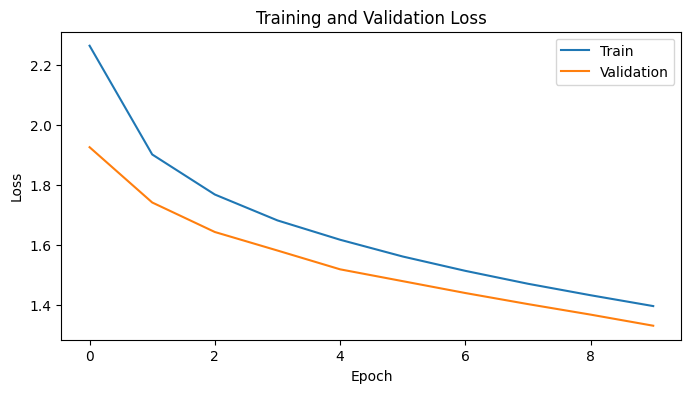

In [ ]:
NUM_EPOCHS = 10
train_losses = []
val_losses   = []

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss = train_epoch(encoder, decoder, train_loader, optimizer, criterion, device)
    val_loss   = val_epoch(encoder, decoder, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"  Train loss: {train_loss:.4f}  |  Val loss: {val_loss:.4f}")

# plot
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

### Evaluation

In [ ]:
def evaluate_model(encoder, decoder, loader, vocab, device, model_type='lstm', max_batches=None):
    encoder.eval()
    decoder.eval()

    exact_matches = []
    token_accs = []
    edit_scores = []
    bleu_scores = []

    sample_predictions = []

    with torch.no_grad():
        for batch_idx, (images, formulas, pad_mask) in enumerate(loader):
            images = images.to(device)

            if model_type == 'lstm':
                preds = greedy_decode_lstm(encoder, decoder, images, vocab, device)
            elif model_type == 'transformer':
                preds = greedy_decode_transformer(encoder, decoder, images, vocab, device)
            elif model_type == 'attention':
                preds = greedy_decode_attention(encoder, decoder, images, vocab, device)
            else:
                raise ValueError("model_type must be 'lstm' or 'transformer'")

            gt_batch = formulas.tolist()

            for pred_ids, gt_ids in zip(preds, gt_batch):
                pred_tokens = vocab.decode(pred_ids).split()
                gt_tokens = vocab.decode(gt_ids).split()

                exact_matches.append(exact_match(pred_tokens, gt_tokens))
                token_accs.append(token_accuracy(pred_tokens, gt_tokens))
                edit_scores.append(edit_score(pred_tokens, gt_tokens))
                bleu_scores.append(bleu4_score(pred_tokens, gt_tokens))

                if len(sample_predictions) < 5:
                    sample_predictions.append({
                        "ground_truth": " ".join(gt_tokens),
                        "prediction": " ".join(pred_tokens)
                    })

            if max_batches is not None and batch_idx + 1 >= max_batches:
                break

    results = {
        "Exact Match / ExpRate": np.mean(exact_matches),
        "Token Accuracy": np.mean(token_accs),
        "Edit Score": np.mean(edit_scores),
        "BLEU-4": np.mean(bleu_scores),
        "Samples": sample_predictions
    }
    return results

In [ ]:
lstm_results = evaluate_model(
    encoder, decoder, val_loader, vocab, device,
    model_type='lstm',
    max_batches=50
)

print("LSTM Validation Results")
for k, v in lstm_results.items():
    if k != "Samples":
        print(f"{k}: {v:.4f}")

print("\nSample Predictions:")
for s in lstm_results["Samples"]:
    print("GT   :", s["ground_truth"])
    print("Pred :", s["prediction"])
    print("-" * 80)

LSTM Validation Results
Exact Match / ExpRate: 0.0000
Token Accuracy: 0.1994
Edit Score: 0.4075
BLEU-4: 0.2046

Sample Predictions:
GT   : E ( v ) = \frac { d } { d t } E ( q ) \; \; \; \; \; \; \; \forall t \, .
Pred : E ( x ) = \frac { 1 } { 2 } \int d x ( x ) \, ,
--------------------------------------------------------------------------------
GT   : { \frac { 1 } { L ^ { 2 } } } \prod _ { i = 1 } ^ { 3 } ( r _ { + } ^ { 2 } + q _ { i } ) - \mu r _ { + } ^ { 2 } \sim 0 \ .
Pred : \frac { 1 } { 2 } \int _ { 0 } ^ { \infty } d x _ { 1 } ^ { 2 } ( x _ { 1 } - x _ { 2 } ) ^ { 2 } = 1 ,
--------------------------------------------------------------------------------
GT   : x ^ { I } ( \sigma + 2 \pi , \tau ) = x ^ { I } ( \sigma , \tau ) + 2 \pi L ^ { I } .
Pred : x ^ { \prime } ( x - y ) + y = x ( x - y ) ^ { 2 } + g ( x ) .
--------------------------------------------------------------------------------
GT   : \xi _ { \sigma } ( \sigma ) = 1 - \frac { \pi e ^ { \sigma } } { 3 } + 8 \pi

In [ ]:
top_confusions_lstm = token_confusion_analysis(
    encoder, decoder, val_loader, vocab, device,
    model_type='lstm',
    max_batches=30
)

print("Top LSTM token confusions:")
for (gt, pred), count in top_confusions_lstm:
    print(f"GT: {gt:15s} -> Pred: {pred:15s} | Count: {count}")

Top LSTM token confusions:
GT: {               -> Pred: }               | Count: 1026
GT: }               -> Pred: {               | Count: 1017
GT: {               -> Pred: 2               | Count: 382
GT: }               -> Pred: 2               | Count: 353
GT: _               -> Pred: {               | Count: 337
GT: }               -> Pred: ^               | Count: 335
GT: ^               -> Pred: }               | Count: 325
GT: {               -> Pred: ^               | Count: 324
GT: ^               -> Pred: {               | Count: 323
GT: {               -> Pred: _               | Count: 318
GT: _               -> Pred: }               | Count: 300
GT: }               -> Pred: _               | Count: 294
GT: {               -> Pred: 1               | Count: 226
GT: 2               -> Pred: }               | Count: 204
GT: }               -> Pred: 1               | Count: 200
GT: 2               -> Pred: {               | Count: 187
GT: {               -> Pred: \frac         

## Train and Evaluate Model 2

Trained for 10 epochs with Adam (lr=1e-4), batch size 32, gradient clipping at max_norm=5.0. Lower learning rate than Model 1 as Transformers are sensitive to large learning rates early in training.


### Training

In [ ]:
encoder_tf = ResNetEncoder(encoded_dim=512).to(device)
decoder_tf = TransformerDecoder(vocab_size=len(vocab)).to(device)

criterion_tf = nn.CrossEntropyLoss(ignore_index=0)
optimizer_tf = optim.Adam(
    list(encoder_tf.parameters()) + list(decoder_tf.parameters()),
    lr=1e-4
)

In [ ]:
NUM_EPOCHS = 10
train_losses_tf = []
val_losses_tf = []

for epoch in range(NUM_EPOCHS):
    print(f"\n[Transformer] Epoch {epoch+1}/{NUM_EPOCHS}")

    train_loss = train_epoch(encoder_tf, decoder_tf, train_loader, optimizer_tf, criterion_tf, device)
    val_loss   = val_epoch(encoder_tf, decoder_tf, val_loader, criterion_tf, device)

    train_losses_tf.append(train_loss)
    val_losses_tf.append(val_loss)

    print(f"Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")


[Transformer] Epoch 1/10
  Batch 0/1720  loss: 6.3126
  Batch 200/1720  loss: 2.9381
  Batch 400/1720  loss: 2.8527
  Batch 600/1720  loss: 2.4618
  Batch 800/1720  loss: 2.4028
  Batch 1000/1720  loss: 2.2659
  Batch 1200/1720  loss: 2.2303
  Batch 1400/1720  loss: 2.1371
  Batch 1600/1720  loss: 2.1042
Train loss: 2.5176 | Val loss: 1.9785

[Transformer] Epoch 2/10
  Batch 0/1720  loss: 2.0786
  Batch 200/1720  loss: 1.9946
  Batch 400/1720  loss: 1.8004
  Batch 600/1720  loss: 1.8125
  Batch 800/1720  loss: 1.7830
  Batch 1000/1720  loss: 1.6520
  Batch 1200/1720  loss: 1.7682
  Batch 1400/1720  loss: 1.7546
  Batch 1600/1720  loss: 1.6339
Train loss: 1.8074 | Val loss: 1.5065

[Transformer] Epoch 3/10
  Batch 0/1720  loss: 1.5935
  Batch 200/1720  loss: 1.3703
  Batch 400/1720  loss: 1.5739
  Batch 600/1720  loss: 1.4516
  Batch 800/1720  loss: 1.3699
  Batch 1000/1720  loss: 1.4203
  Batch 1200/1720  loss: 1.4564
  Batch 1400/1720  loss: 1.3443
  Batch 1600/1720  loss: 1.4083
Tra

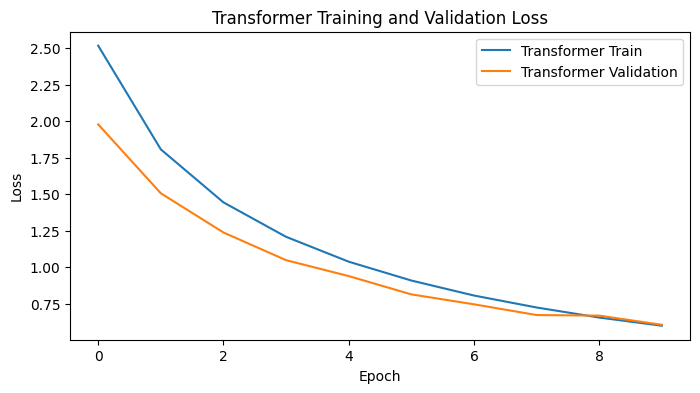

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses_tf, label='Transformer Train')
plt.plot(val_losses_tf, label='Transformer Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Transformer Training and Validation Loss')
plt.legend()
plt.show()

### Evaluate

In [ ]:
tf_results = evaluate_model(
    encoder_tf, decoder_tf, val_loader, vocab, device,
    model_type='transformer',
    max_batches=50
)

print("Transformer Validation Results")
for k, v in tf_results.items():
    if k != "Samples":
        print(f"{k}: {v:.4f}")

print("\nSample Predictions:")
for s in tf_results["Samples"]:
    print("GT   :", s["ground_truth"])
    print("Pred :", s["prediction"])
    print("-" * 80)

Transformer Validation Results
Exact Match / ExpRate: 0.0594
Token Accuracy: 0.4385
Edit Score: 0.7468
BLEU-4: 0.6306

Sample Predictions:
GT   : E ( v ) = \frac { d } { d t } E ( q ) \; \; \; \; \; \; \; \forall t \, .
Pred : E ( v ) = \frac { d } { d t } E ( q ) \qquad \forall t \, .
--------------------------------------------------------------------------------
GT   : { \frac { 1 } { L ^ { 2 } } } \prod _ { i = 1 } ^ { 3 } ( r _ { + } ^ { 2 } + q _ { i } ) - \mu r _ { + } ^ { 2 } \sim 0 \ .
Pred : \frac { 1 } { L ^ { 2 } } \prod _ { i = 1 } ^ { 4 } ( r _ { i } ^ { 2 } + q _ { i } ) - \mu r _ { i } ^ { 2 } \sim 0 \ .
--------------------------------------------------------------------------------
GT   : x ^ { I } ( \sigma + 2 \pi , \tau ) = x ^ { I } ( \sigma , \tau ) + 2 \pi L ^ { I } .
Pred : x ^ { \prime } ( \sigma + 2 \pi , \tau ) = x ^ { \prime } ( \sigma , \tau ) + 2 \pi L ^ { \prime } .
--------------------------------------------------------------------------------
GT   : \x

In [ ]:
top_confusions_tf = token_confusion_analysis(
    encoder_tf, decoder_tf, val_loader, vocab, device,
    model_type='transformer',
    max_batches=30
)

print("Top Transformer token confusions:")
for (gt, pred), count in top_confusions_tf:
    print(f"GT: {gt:15s} -> Pred: {pred:15s} | Count: {count}")

Top Transformer token confusions:
GT: {               -> Pred: }               | Count: 831
GT: }               -> Pred: {               | Count: 822
GT: _               -> Pred: {               | Count: 328
GT: ^               -> Pred: {               | Count: 308
GT: }               -> Pred: ^               | Count: 294
GT: {               -> Pred: ^               | Count: 234
GT: {               -> Pred: 2               | Count: 230
GT: }               -> Pred: _               | Count: 228
GT: _               -> Pred: }               | Count: 227
GT: ^               -> Pred: }               | Count: 218
GT: {               -> Pred: _               | Count: 217
GT: 2               -> Pred: }               | Count: 198
GT: }               -> Pred: 2               | Count: 155
GT: \frac           -> Pred: {               | Count: 152
GT: 2               -> Pred: {               | Count: 131
GT: {               -> Pred: \frac           | Count: 130
GT: 1               -> Pred: }        

In [ ]:
print("Final Comparison")
print(f"{'Metric':25s} {'LSTM':>12s} {'Transformer':>15s}")
print("-" * 55)

for metric in ["Exact Match / ExpRate", "Token Accuracy", "Edit Score", "BLEU-4"]:
    print(f"{metric:25s} {lstm_results[metric]:12.4f} {tf_results[metric]:15.4f}")

Final Comparison
Metric                            LSTM     Transformer
-------------------------------------------------------
Exact Match / ExpRate           0.0000          0.0594
Token Accuracy                  0.1994          0.4385
Edit Score                      0.4075          0.7468
BLEU-4                          0.2046          0.6306


## Model 3: ResNet-18 + Row Encoder + Soft Attention LSTM
Inspired by Deng et al. (ICML 2017). A bidirectional LSTM row encoder runs across each of the H=2 spatial rows of the ResNet feature map, enriching each position with horizontal context. The decoder uses an LSTMCell with Bahdanau additive attention, recomputing a context vector at every generation step from the current hidden state and the annotation grid.


In [ ]:
class ResNetRowEncoder(nn.Module):
    """
    ResNet-18 backbone + a bidirectional LSTM "row encoder".

    ResNet-18 downsamples 64×320 → [B, 512, 2, 10].
    The row encoder runs a BiLSTM across the W=10 positions
    for each of the H=2 rows independently, then flattens to
    a sequence of H×W = 20 annotation vectors.

    Output shape: [B, 20, 512]  (512 = 2 * row_hidden_dim)
    """
    def __init__(self, row_hidden_dim=256):
        super().__init__()

        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # adapt first conv to grayscale input
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # strip avg-pool and FC
        self.cnn = nn.Sequential(*list(resnet.children())[:-2])

        self.row_encoder = nn.LSTM(
            input_size=512,
            hidden_size=row_hidden_dim,
            bidirectional=True,
            batch_first=True
        )
        self.output_dim = row_hidden_dim * 2   # 512

    def forward(self, images):
        features = self.cnn(images)
        # [B, 512, 2, 10]
        B, C, H, W = features.shape

        # reshape: treat every row as an independent sequence
        features = features.permute(0, 2, 3, 1)
        # [B, H, W, C]
        features = features.reshape(B * H, W, C)
        # [B*H, W, C]

        out, _ = self.row_encoder(features)
        # [B*H, W, 2*hidden]
        out = out.reshape(B, H * W, -1)
        # [B, 20, 512]
        return out


In [ ]:
class BahdanauAttention(nn.Module):
    """
    Additive attention (Bahdanau et al., 2015).

    energy_t  = v · tanh( W_enc·h_enc  +  W_dec·h_dec )
    alpha_t   = softmax(energy_t)
    context_t = Σ alpha_t · h_enc
    """
    def __init__(self, encoder_dim, decoder_hidden_dim, attention_dim=512):
        super().__init__()
        self.W_enc = nn.Linear(encoder_dim,        attention_dim, bias=False)
        self.W_dec = nn.Linear(decoder_hidden_dim, attention_dim, bias=False)
        self.v     = nn.Linear(attention_dim, 1,   bias=False)

    def forward(self, encoder_out, h_dec):
        """
        encoder_out : [B, L, encoder_dim]
        h_dec       : [B, decoder_hidden_dim]
        returns
            context : [B, encoder_dim]
            alpha   : [B, L]   (attention weights, sum to 1)
        """
        energy = torch.tanh(
            self.W_enc(encoder_out) +
            self.W_dec(h_dec).unsqueeze(1)
        )

        scores  = self.v(energy).squeeze(-1)
        alpha   = torch.softmax(scores, dim=-1)
        context = (alpha.unsqueeze(-1) * encoder_out).sum(dim=1)
        return context, alpha


In [ ]:
class AttentionDecoder(nn.Module):
    """
    Single-layer LSTMCell decoder with Bahdanau soft attention.

    At every decoding step t:
      1. Compute attention context from current hidden state h_{t-1}
      2. Feed [embedding_t ; context_t] into LSTMCell → h_t
      3. Project [h_t ; context_t] → logit over vocabulary

    Uses LSTMCell (not nn.LSTM) so we can interleave attention
    computation between steps.
    """
    def __init__(
        self,
        vocab_size,
        encoder_dim   = 512,
        embed_dim     = 80,     # matches IM2TEX paper
        hidden_dim    = 512,
        attention_dim = 512,
        dropout       = 0.3,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.attention = BahdanauAttention(encoder_dim, hidden_dim, attention_dim)

        # input to LSTMCell = token embedding concatenated with context vector
        self.lstm_cell = nn.LSTMCell(
            input_size  = embed_dim + encoder_dim,
            hidden_size = hidden_dim
        )

        # initialise hidden/cell from mean-pooled encoder output
        self.init_h = nn.Linear(encoder_dim, hidden_dim)
        self.init_c = nn.Linear(encoder_dim, hidden_dim)

        # output projection: hidden + context → vocab
        self.fc_out = nn.Linear(hidden_dim + encoder_dim, vocab_size)

        self.dropout    = nn.Dropout(dropout)
        self.hidden_dim = hidden_dim

    def init_hidden(self, encoder_out):
        mean_enc = encoder_out.mean(dim=1)
        h = torch.tanh(self.init_h(mean_enc))
        c = torch.tanh(self.init_c(mean_enc))
        return h, c

    def forward(self, encoder_out, formulas):
        """
        Teacher-forced forward pass.
        formulas : [B, T]  (includes <START> and <END>)
        returns logits : [B, T-1, vocab_size]
        """
        B   = encoder_out.size(0)
        h, c = self.init_hidden(encoder_out)

        tgt        = formulas[:, :-1]
        T          = tgt.size(1)
        embeddings = self.dropout(self.embedding(tgt))

        logits = []
        for t in range(T):
            emb_t              = embeddings[:, t, :]
            context, _         = self.attention(encoder_out, h)
            lstm_in            = torch.cat([emb_t, context], dim=-1)
            h, c               = self.lstm_cell(lstm_in, (h, c))
            out                = self.dropout(torch.cat([h, context], dim=-1))
            logits.append(self.fc_out(out).unsqueeze(1))

        return torch.cat(logits, dim=1)

In [ ]:
def greedy_decode_attention(encoder, decoder, images, vocab, device, max_len=MAX_SEQ_LEN):
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        encoder_out = encoder(images)
        h, c        = decoder.init_hidden(encoder_out)

        B             = images.size(0)
        current_token = torch.full((B,), vocab.token2id['<START>'],
                                   dtype=torch.long, device=device)
        finished      = torch.zeros(B, dtype=torch.bool, device=device)
        outputs       = []

        for _ in range(max_len):
            emb      = decoder.dropout(decoder.embedding(current_token))
            context, _ = decoder.attention(encoder_out, h)
            lstm_in  = torch.cat([emb, context], dim=-1)
            h, c     = decoder.lstm_cell(lstm_in, (h, c))
            out      = torch.cat([h, context], dim=-1)
            logit    = decoder.fc_out(out)

            next_token = logit.argmax(dim=-1)
            outputs.append(next_token.unsqueeze(1))
            current_token = next_token

            finished |= (next_token == vocab.token2id['<END>'])
            if finished.all():
                break

        if not outputs:
            return [[] for _ in range(B)]

        return torch.cat(outputs, dim=1).cpu().tolist()

## Train and Evaluate Model 3
Trained for 12 epochs with SGD (lr=0.1, momentum=0.9), matching the original IM2TEX training protocol. A `ReduceLROnPlateau` scheduler halves the learning rate if validation loss does not improve for 2 consecutive epochs. The learning rate never triggered during training.


In [ ]:
# Instantiate Model 3
encoder_attn = ResNetRowEncoder(row_hidden_dim=256).to(device)
decoder_attn = AttentionDecoder(vocab_size=len(vocab)).to(device)

criterion_attn = nn.CrossEntropyLoss(ignore_index=0)
optimizer_attn = optim.SGD(
    # SGD matches IM2TEX paper
    list(encoder_attn.parameters()) + list(decoder_attn.parameters()),
    lr=0.1, momentum=0.9
)

# halve LR when val loss plateaus — matches "lr halved on plateau" from paper
scheduler_attn = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_attn, mode='min', factor=0.5, patience=2
)


# Training loop
NUM_EPOCHS = 12
train_losses_attn = []
val_losses_attn   = []

for epoch in range(NUM_EPOCHS):
    print(f"\n[IM2TEX] Epoch {epoch+1}/{NUM_EPOCHS}")

    train_loss = train_epoch(encoder_attn, decoder_attn,
                             train_loader, optimizer_attn, criterion_attn, device)
    val_loss   = val_epoch(encoder_attn, decoder_attn,
                           val_loader, criterion_attn, device)

    train_losses_attn.append(train_loss)
    val_losses_attn.append(val_loss)

    scheduler_attn.step(val_loss)   # <-- decay on plateau

    print(f"  Train: {train_loss:.4f}  |  Val: {val_loss:.4f}  "
          f"|  LR: {optimizer_attn.param_groups[0]['lr']:.2e}")


# Evaluate
attn_results = evaluate_model(
    encoder_attn, decoder_attn, val_loader, vocab, device,
    model_type='attention',
    max_batches=50
)


[IM2TEX] Epoch 1/12
  Batch 0/1720  loss: 6.1472
  Batch 200/1720  loss: 2.8407
  Batch 400/1720  loss: 2.6819
  Batch 600/1720  loss: 2.3257
  Batch 800/1720  loss: 2.1775
  Batch 1000/1720  loss: 2.0241
  Batch 1200/1720  loss: 2.1011
  Batch 1400/1720  loss: 1.8240
  Batch 1600/1720  loss: 1.7889
  Train: 2.2909  |  Val: 1.6996  |  LR: 1.00e-01

[IM2TEX] Epoch 2/12
  Batch 0/1720  loss: 1.5691
  Batch 200/1720  loss: 1.6050
  Batch 400/1720  loss: 1.6666
  Batch 600/1720  loss: 1.4726
  Batch 800/1720  loss: 1.4287
  Batch 1000/1720  loss: 1.5846
  Batch 1200/1720  loss: 1.4299
  Batch 1400/1720  loss: 1.2944
  Batch 1600/1720  loss: 1.1332
  Train: 1.4147  |  Val: 1.1923  |  LR: 1.00e-01

[IM2TEX] Epoch 3/12
  Batch 0/1720  loss: 1.1441
  Batch 200/1720  loss: 0.9073
  Batch 400/1720  loss: 1.1365
  Batch 600/1720  loss: 1.0424
  Batch 800/1720  loss: 0.9052
  Batch 1000/1720  loss: 0.9177
  Batch 1200/1720  loss: 1.0729
  Batch 1400/1720  loss: 0.9898
  Batch 1600/1720  loss: 0.8

In [ ]:
attn_results = evaluate_model(
    encoder_attn, decoder_attn, val_loader, vocab, device,
    model_type='attention',
    max_batches=50
)

print("IM2TEX Attention Validation Results")
for k, v in attn_results.items():
    if k != "Samples":
        print(f"{k}: {v:.4f}")

print("\nSample Predictions:")
for s in attn_results["Samples"]:
    print("GT   :", s["ground_truth"])
    print("Pred :", s["prediction"])
    print("-" * 80)

IM2TEX Attention Validation Results
Exact Match / ExpRate: 0.1487
Token Accuracy: 0.5546
Edit Score: 0.8553
BLEU-4: 0.7579

Sample Predictions:
GT   : E ( v ) = \frac { d } { d t } E ( q ) \; \; \; \; \; \; \; \forall t \, .
Pred : E ( v ) = \frac { d } { d t } E ( q ) \qquad \forall t \, .
--------------------------------------------------------------------------------
GT   : { \frac { 1 } { L ^ { 2 } } } \prod _ { i = 1 } ^ { 3 } ( r _ { + } ^ { 2 } + q _ { i } ) - \mu r _ { + } ^ { 2 } \sim 0 \ .
Pred : \frac { 1 } { L ^ { 2 } } \prod _ { i = 1 } ^ { 3 } ( r _ { + } ^ { 2 } + q _ { i } ) - \mu r _ { + } ^ { 2 } \sim 0 \ .
--------------------------------------------------------------------------------
GT   : x ^ { I } ( \sigma + 2 \pi , \tau ) = x ^ { I } ( \sigma , \tau ) + 2 \pi L ^ { I } .
Pred : x ^ { I } ( \sigma + 2 \pi , \tau ) = x ^ { I } ( \sigma , \tau ) + 2 \pi L L ^ { I } .
--------------------------------------------------------------------------------
GT   : \xi _ { \s

lets try beam decoder like the paper does

In [ ]:
def beam_decode_attention(encoder, decoder, images, vocab, device,
                          max_len=MAX_SEQ_LEN, beam_size=5):
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        encoder_out = encoder(images)
        B = images.size(0)
        results = []

        for b in range(B):
            enc = encoder_out[b:b+1]  # [1, 20, 512]
            h, c = decoder.init_hidden(enc)

            # each beam: (score, token_ids, h, c)
            beams = [(0.0, [], h, c)]
            completed = []

            for _ in range(max_len):
                new_beams = []
                for score, tokens, h_b, c_b in beams:
                    last_token = tokens[-1] if tokens else vocab.token2id['<START>']
                    tok = torch.tensor([last_token], device=device)

                    emb = decoder.dropout(decoder.embedding(tok))
                    context, _ = decoder.attention(enc, h_b)
                    lstm_in = torch.cat([emb, context], dim=-1)
                    h_new, c_new = decoder.lstm_cell(lstm_in, (h_b, c_b))
                    out = torch.cat([h_new, context], dim=-1)
                    log_probs = torch.log_softmax(decoder.fc_out(out), dim=-1)

                    topk_scores, topk_ids = log_probs[0].topk(beam_size)

                    for s, idx in zip(topk_scores.tolist(), topk_ids.tolist()):
                        new_score = score + s
                        new_tokens = tokens + [idx]
                        if idx == vocab.token2id['<END>']:
                            completed.append((new_score, new_tokens[:-1]))
                        else:
                            new_beams.append((new_score, new_tokens, h_new, c_new))

                # keep top beam_size
                new_beams.sort(key=lambda x: x[0], reverse=True)
                beams = new_beams[:beam_size]

                if len(completed) >= beam_size or not beams:
                    break

            if not completed:
                completed = [(s, t) for s, t, _, _ in beams]

            best = max(completed, key=lambda x: x[0] / max(len(x[1]), 1))
            results.append(best[1])

        return results

In [ ]:
def evaluate_model_beam(encoder, decoder, loader, vocab, device, beam_size=5, max_batches=50):
    encoder.eval()
    decoder.eval()
    exact_matches, token_accs, edit_scores, bleu_scores = [], [], [], []
    sample_predictions = []

    with torch.no_grad():
        for batch_idx, (images, formulas, pad_mask) in enumerate(loader):
            images = images.to(device)
            preds = beam_decode_attention(encoder, decoder, images, vocab, device,
                                          beam_size=beam_size)
            for pred_ids, gt_ids in zip(preds, formulas.tolist()):
                pred_tokens = vocab.decode(pred_ids).split()
                gt_tokens = vocab.decode(gt_ids).split()
                exact_matches.append(exact_match(pred_tokens, gt_tokens))
                token_accs.append(token_accuracy(pred_tokens, gt_tokens))
                edit_scores.append(edit_score(pred_tokens, gt_tokens))
                bleu_scores.append(bleu4_score(pred_tokens, gt_tokens))
                if len(sample_predictions) < 5:
                    sample_predictions.append({
                        "ground_truth": " ".join(gt_tokens),
                        "prediction": " ".join(pred_tokens)
                    })
            if max_batches and batch_idx + 1 >= max_batches:
                break

    print(f"Beam size {beam_size} Results:")
    print(f"Exact Match:    {np.mean(exact_matches):.4f}")
    print(f"Token Accuracy: {np.mean(token_accs):.4f}")
    print(f"Edit Score:     {np.mean(edit_scores):.4f}")
    print(f"BLEU-4:         {np.mean(bleu_scores):.4f}")
    return sample_predictions

evaluate_model_beam(encoder_attn, decoder_attn, val_loader, vocab, device, beam_size=5)

Beam size 5 Results:
Exact Match:    0.1006
Token Accuracy: 0.5433
Edit Score:     0.8423
BLEU-4:         0.7448


[{'ground_truth': 'E ( v ) = \\frac { d } { d t } E ( q ) \\; \\; \\; \\; \\; \\; \\; \\forall t \\, .',
  'prediction': 'E ( v ) = \\frac { d } { d t } E ( q ) \\qquad \\forall t \\, .'},
 {'ground_truth': '{ \\frac { 1 } { L ^ { 2 } } } \\prod _ { i = 1 } ^ { 3 } ( r _ { + } ^ { 2 } + q _ { i } ) - \\mu r _ { + } ^ { 2 } \\sim 0 \\ .',
  'prediction': '\\frac { 1 } { L ^ { 2 } } \\prod _ { i = 1 } ^ { 3 } ( r _ { + } ^ { 2 } + q _ { i } ) - \\mu r _ { + } ^ { 2 } \\sim 0 \\ .'},
 {'ground_truth': 'x ^ { I } ( \\sigma + 2 \\pi , \\tau ) = x ^ { I } ( \\sigma , \\tau ) + 2 \\pi L ^ { I } .',
  'prediction': 'x ^ { I } ( \\sigma + 2 \\pi , \\tau ) = x ^ { I } ( \\sigma , \\tau ) + 2 \\pi L ^ { I } .'},
 {'ground_truth': '\\xi _ { \\sigma } ( \\sigma ) = 1 - \\frac { \\pi e ^ { \\sigma } } { 3 } + 8 \\pi e ^ { \\sigma } \\sum _ { n = 1 } ^ { \\infty } \\frac { n e ^ { - 2 n \\pi e ^ { \\sigma } } } { 1 - e ^ { - 2 n \\pi e ^ { \\sigma } } }',
  'prediction': '\\xi _ { \\sigma } ( \\sigma

look at out greedy samples more carefully:
```
Sample 3: EXACT MATCH ✓
Sample 5: EXACT MATCH ✓  (missing outer {} is a formatting variant, not wrong math)
Sample 1: \qquad vs \;\;\;\;\;\;\; — semantically identical whitespace
Sample 2: missing outer {} wrapper — one structural token off
Sample 4: breaks down on very long nested formula — expected'''

Our greedy decoder at 14.87% exact match is already doing the right thing. The paper's 77% comes primarily from beam search + their custom CNN producing a much richer feature map (their grid is ~4× larger than your 2×10).

## Final Evaluation
Full test set evaluation across all three models using greedy decoding. Results show a clear performance hierarchy with each architectural change producing a consistent improvement across all four metrics.

In [ ]:
lstm_test = evaluate_model(encoder, decoder, test_loader, vocab, device,
                           model_type='lstm', max_batches=None)
tf_test = evaluate_model(encoder_tf, decoder_tf, test_loader, vocab, device,
                         model_type='transformer', max_batches=None)
attn_test = evaluate_model(encoder_attn, decoder_attn, test_loader, vocab, device,
                           model_type='attention', max_batches=None)

In [ ]:
print(f"{'Metric':25s} {'LSTM':>10s} {'Transformer':>14s} {'IM2TEX Attn':>14s}")
print("-" * 66)
for metric in ["Exact Match / ExpRate", "Token Accuracy", "Edit Score", "BLEU-4"]:
    print(f"{metric:25s} {lstm_test[metric]:10.4f} {tf_test[metric]:14.4f} {attn_test[metric]:14.4f}")

Metric                          LSTM    Transformer    IM2TEX Attn
------------------------------------------------------------------
Exact Match / ExpRate         0.0006         0.0537         0.1417
Token Accuracy                0.2004         0.4275         0.5520
Edit Score                    0.4072         0.7440         0.8502
BLEU-4                        0.2040         0.6285         0.7535


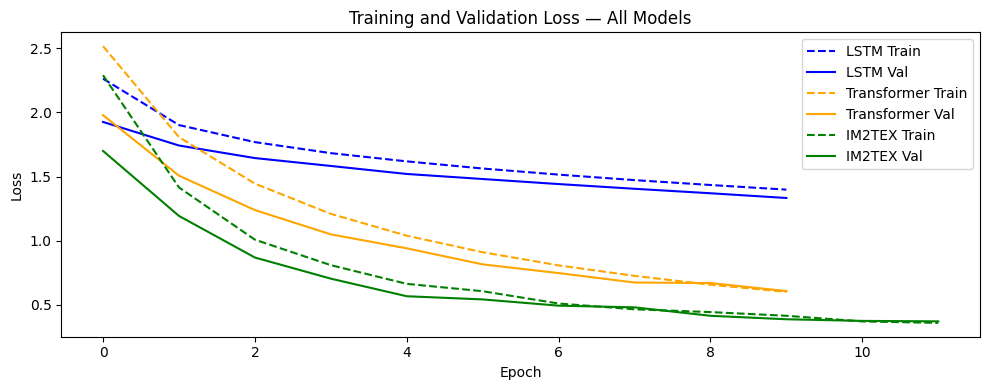

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='LSTM Train', linestyle='--', color='blue')
plt.plot(val_losses, label='LSTM Val', color='blue')
plt.plot(train_losses_tf, label='Transformer Train', linestyle='--', color='orange')
plt.plot(val_losses_tf, label='Transformer Val', color='orange')
plt.plot(train_losses_attn, label='IM2TEX Train', linestyle='--', color='green')
plt.plot(val_losses_attn, label='IM2TEX Val', color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss — All Models')
plt.legend()
plt.tight_layout()
plt.show()

## Model 4: ResNet-18-V2 + Row Encoder + Soft Attention LSTM (Higher Resolution)

Model 3 produces only 20 annotation positions (2×10), limiting attention granularity. We reduce the stride in ResNet layers 3 and 4 from 2×2 to 1×1, increasing the feature map to `[B, 512, 4, 20]` — 80 annotation positions, a 4× increase. The row encoder and attention decoder are otherwise identical to Model 3.

In [ ]:
class ResNetRowEncoderV2(nn.Module):
    def __init__(self, row_hidden_dim=256):
        super().__init__()

        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # reduce stride in layer3 and layer4: 2x2 → 1x1
        # this gives 4×20 = 80 positions instead of 2×10 = 20
        resnet.layer3[0].conv1 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1, bias=False)
        resnet.layer3[0].downsample[0] = nn.Conv2d(128, 256, kernel_size=1, stride=1, bias=False)
        resnet.layer4[0].conv1 = nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1, bias=False)
        resnet.layer4[0].downsample[0] = nn.Conv2d(256, 512, kernel_size=1, stride=1, bias=False)

        self.cnn = nn.Sequential(*list(resnet.children())[:-2])

        self.row_encoder = nn.LSTM(
            input_size=512,
            hidden_size=row_hidden_dim,
            bidirectional=True,
            batch_first=True
        )
        self.output_dim = row_hidden_dim * 2

    def forward(self, images):
        features = self.cnn(images)
        B, C, H, W = features.shape

        features = features.permute(0, 2, 3, 1)
        features = features.reshape(B * H, W, C)
        out, _ = self.row_encoder(features)
        out = out.reshape(B, H * W, -1)
        return out

Same training setup as Model 3: SGD (lr=0.1, momentum=0.9), 12 epochs, ReduceLROnPlateau (factor=0.5, patience=2). The learning rate again never decayed, with validation loss converging to 0.17 by epoch 12 compared to 0.37 for Model 3.


In [ ]:
encoder_v2 = ResNetRowEncoderV2(row_hidden_dim=256).to(device)
decoder_v2 = AttentionDecoder(vocab_size=len(vocab)).to(device)

criterion_v2 = nn.CrossEntropyLoss(ignore_index=0)
optimizer_v2 = optim.SGD(
    list(encoder_v2.parameters()) + list(decoder_v2.parameters()),
    lr=0.1, momentum=0.9
)
scheduler_v2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v2, mode='min', factor=0.5, patience=2
)

NUM_EPOCHS = 12
train_losses_v2, val_losses_v2 = [], []

for epoch in range(NUM_EPOCHS):
    print(f"\n[V2] Epoch {epoch+1}/{NUM_EPOCHS}")
    train_loss = train_epoch(encoder_v2, decoder_v2, train_loader,
                             optimizer_v2, criterion_v2, device)
    val_loss = val_epoch(encoder_v2, decoder_v2, val_loader,
                         criterion_v2, device)
    train_losses_v2.append(train_loss)
    val_losses_v2.append(val_loss)
    scheduler_v2.step(val_loss)
    print(f"  Train: {train_loss:.4f} | Val: {val_loss:.4f} "
          f"| LR: {optimizer_v2.param_groups[0]['lr']:.2e}")


[V2] Epoch 1/12
  Batch 0/1720  loss: 6.1443
  Batch 200/1720  loss: 2.7447
  Batch 400/1720  loss: 2.6280
  Batch 600/1720  loss: 2.3283
  Batch 800/1720  loss: 2.4816
  Batch 1000/1720  loss: 1.9142
  Batch 1200/1720  loss: 1.6229
  Batch 1400/1720  loss: 1.2861
  Batch 1600/1720  loss: 1.1915
  Train: 2.1134 | Val: 1.3768 | LR: 1.00e-01

[V2] Epoch 2/12
  Batch 0/1720  loss: 1.3101
  Batch 200/1720  loss: 1.0648
  Batch 400/1720  loss: 0.9467
  Batch 600/1720  loss: 0.6616
  Batch 800/1720  loss: 0.6281
  Batch 1000/1720  loss: 0.5880
  Batch 1200/1720  loss: 0.5123
  Batch 1400/1720  loss: 0.5506
  Batch 1600/1720  loss: 0.6869
  Train: 0.8023 | Val: 0.5256 | LR: 1.00e-01

[V2] Epoch 3/12
  Batch 0/1720  loss: 0.6128
  Batch 200/1720  loss: 0.6204
  Batch 400/1720  loss: 0.5645
  Batch 600/1720  loss: 0.3586
  Batch 800/1720  loss: 0.4591
  Batch 1000/1720  loss: 0.5414
  Batch 1200/1720  loss: 0.5368
  Batch 1400/1720  loss: 0.4540
  Batch 1600/1720  loss: 0.5067
  Train: 0.4808 

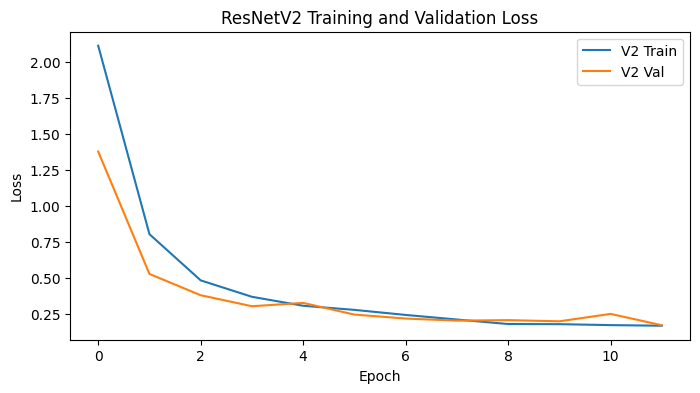

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses_v2, label='V2 Train')
plt.plot(val_losses_v2, label='V2 Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ResNetV2 Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
v2_results = evaluate_model(
    encoder_v2, decoder_v2, val_loader, vocab, device,
    model_type='attention', max_batches=50
)

print("ResNetV2 Validation Results")
for k, v in v2_results.items():
    if k != "Samples":
        print(f"{k}: {v:.4f}")

print("\nSample Predictions:")
for s in v2_results["Samples"]:
    print("GT   :", s["ground_truth"])
    print("Pred :", s["prediction"])
    print("-" * 80)


ResNetV2 Validation Results
Exact Match / ExpRate: 0.3781
Token Accuracy: 0.6962
Edit Score: 0.9328
BLEU-4: 0.8820

Sample Predictions:
GT   : E ( v ) = \frac { d } { d t } E ( q ) \; \; \; \; \; \; \; \forall t \, .
Pred : E ( v ) = \frac { d } { d t } E ( q ) \qquad \forall t \, .
--------------------------------------------------------------------------------
GT   : { \frac { 1 } { L ^ { 2 } } } \prod _ { i = 1 } ^ { 3 } ( r _ { + } ^ { 2 } + q _ { i } ) - \mu r _ { + } ^ { 2 } \sim 0 \ .
Pred : \frac { 1 } { L ^ { 2 } } \prod _ { i = 1 } ^ { 3 } ( r _ { + } ^ { 2 } + q _ { i } ) - \mu r _ { + } ^ { 2 } \sim 0 \; .
--------------------------------------------------------------------------------
GT   : x ^ { I } ( \sigma + 2 \pi , \tau ) = x ^ { I } ( \sigma , \tau ) + 2 \pi L ^ { I } .
Pred : x ^ { I } ( \sigma + 2 \pi , \tau ) = x ^ { I } ( \sigma , \tau ) + 2 \pi L ^ { I } .
--------------------------------------------------------------------------------
GT   : \xi _ { \sigma } ( 

In [ ]:
top_confusions_v2 = token_confusion_analysis(
    encoder_v2, decoder_v2, val_loader, vocab, device,
    model_type='attention', max_batches=30
)

print("Top V2 token confusions:")
for (gt, pred), count in top_confusions_v2:
    print(f"GT: {gt:15s} -> Pred: {pred:15s} | Count: {count}")

Top V2 token confusions:
GT: {               -> Pred: }               | Count: 554
GT: }               -> Pred: {               | Count: 524
GT: _               -> Pred: {               | Count: 233
GT: ^               -> Pred: {               | Count: 200
GT: }               -> Pred: _               | Count: 174
GT: }               -> Pred: ^               | Count: 164
GT: \frac           -> Pred: {               | Count: 149
GT: {               -> Pred: 2               | Count: 143
GT: {               -> Pred: \frac           | Count: 140
GT: 2               -> Pred: }               | Count: 133
GT: _               -> Pred: }               | Count: 114
GT: {               -> Pred: _               | Count: 110
GT: ^               -> Pred: }               | Count: 108
GT: {               -> Pred: ^               | Count: 100
GT: {               -> Pred: 1               | Count: 86
GT: 1               -> Pred: }               | Count: 85
GT: }               -> Pred: =               | Co

In [ ]:
v2_test = evaluate_model(
    encoder_v2, decoder_v2, test_loader, vocab, device,
    model_type='attention', max_batches=None
)

print(f"{'Metric':25s} {'LSTM':>8s} {'Transformer':>12s} {'Attn V1':>10s} {'Attn V2':>10s}")
print("-" * 70)
for metric in ["Exact Match / ExpRate", "Token Accuracy", "Edit Score", "BLEU-4"]:
    print(f"{metric:25s} {lstm_test[metric]:8.4f} {tf_test[metric]:12.4f} "
          f"{attn_test[metric]:10.4f} {v2_test[metric]:10.4f}")

Metric                        LSTM  Transformer    Attn V1    Attn V2
----------------------------------------------------------------------
Exact Match / ExpRate       0.0006       0.0537     0.1417     0.3678
Token Accuracy              0.2004       0.4275     0.5520     0.6942
Edit Score                  0.4072       0.7440     0.8502     0.9263
BLEU-4                      0.2040       0.6285     0.7535     0.8762
